## Imports

In [8]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux f9ed2311dd60 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [9]:
import L09_05_01_discrete_bayes_dog_utils as ut

In [10]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

# Tracking a Dog

## Problem Definition

- There is a dog with a sensor
- The dog wanders around the offices and halls
- The sensor reports if the dog is in front of a door or a hall
- There are 10 positions in the hallway, numbered 0 to 9
- The hallway is circular so after 9, the position is 0

## A Simple Example

In [11]:
# At the beginning, we don't know where the dog is.
# The prior is: all the positions are equiprobable.
belief = np.array([1 / 10] * 10)
print(belief)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


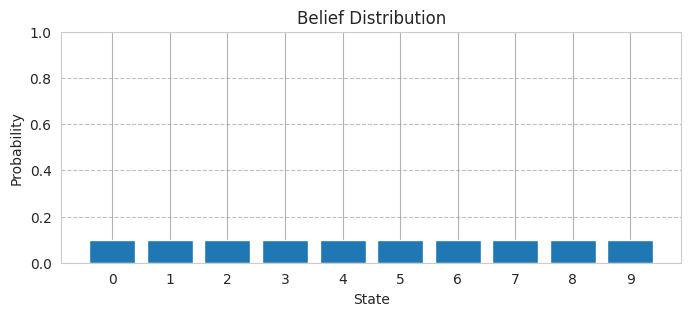

In [12]:
ut.plot_belief(belief)

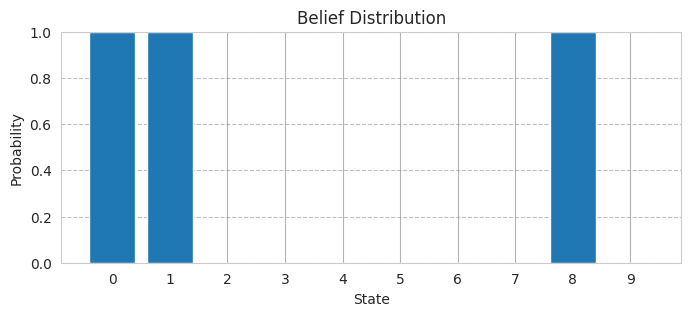

In [13]:
# The map of the office is the following.
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])
ut.plot_belief(hallway)

- The sensor returns always the correct answer.
- The first reading from the sensor is "door"
- The dog is in front of a door, but we don't know which one

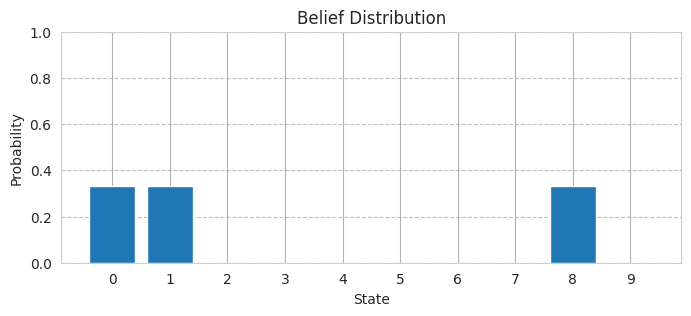

In [14]:
belief = np.array([1 / 3, 1 / 3, 0, 0, 0, 0, 0, 0, 1 / 3, 0])
ut.plot_belief(belief)

- The readings is "door", "move right", "door"
- The only location possible is position #1

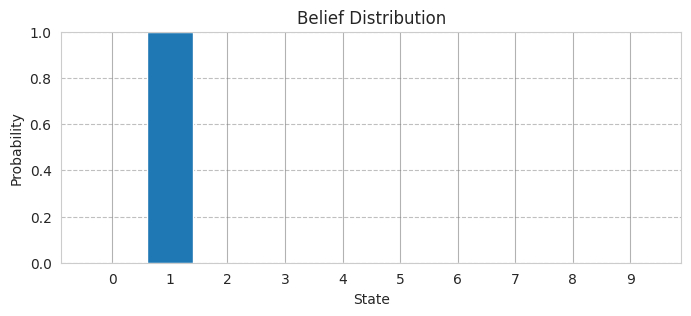

In [15]:
belief = np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
ut.plot_belief(belief)

## Noisy Sensors

- If the sensor is not reliable, it seemed that it's impossible to determine where the dog is
- How can you conclude anything, if you are always unsure?


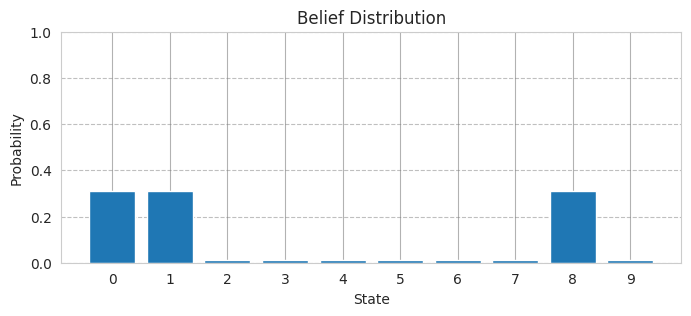

In [16]:
belief = np.array([0.31, 0.31, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.31, 0.01])
ut.plot_belief(belief)

- Testing shows that the sensor is 3 times more likely to be right than wrong

belief: [0.3 0.3 0.1 0.1 0.1 0.1 0.1 0.1 0.3 0.1]
sum = 1.6000000000000003


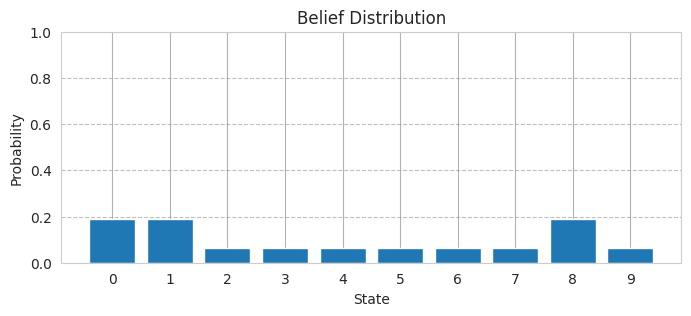

In [18]:
def update_belief(
    hall: np.ndarray, belief: np.ndarray, z: int, correct_scale: float
) -> None:
    """
    Update belief in-place based on a measurement.

    Scales belief values by correct_scale for positions that match the
    measurement z.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param belief: Array representing current belief distribution
    :param z: Measurement value (0 or 1)
    :param correct_scale: Scale factor for matching positions
    """
    for i, val in enumerate(hall):
        if val == z:
            belief[i] *= correct_scale


belief = np.array([0.1] * 10)
reading = 1  # 1 is 'door'
update_belief(hallway, belief, z=reading, correct_scale=3.0)
print("belief:", belief)
print("sum =", sum(belief))
belief /= sum(belief)
ut.plot_belief(belief)

sum = 1.0
probability of door = 0.1875
probability of wall = 0.06249999999999999


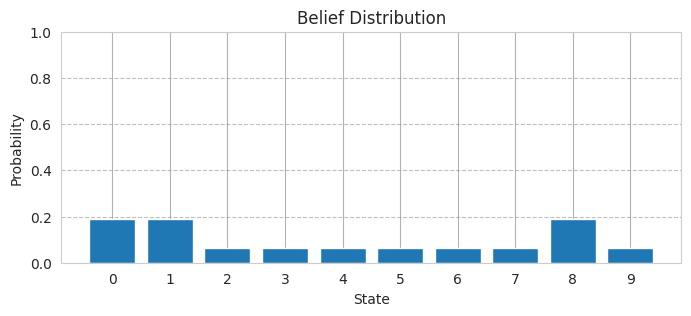

In [19]:
from filterpy.discrete_bayes import normalize


def scaled_update(
    hall: np.ndarray, belief: np.ndarray, z: int, z_prob: float
) -> None:
    """
    Update belief using scaled likelihood based on measurement probability.

    Computes a scale factor from the measurement probability and applies it
    to positions matching the measurement, then normalizes.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param belief: Array representing current belief distribution
    :param z: Measurement value (0 or 1)
    :param z_prob: Probability that the measurement is correct
    """
    scale = z_prob / (1.0 - z_prob)
    belief[hall == z] *= scale
    normalize(belief)


belief = np.array([0.1] * 10)
scaled_update(hallway, belief, z=1, z_prob=0.75)

print("sum =", sum(belief))
print("probability of door =", belief[0])
print("probability of wall =", belief[2])
ut.plot_belief(belief)

- Generalizing;
  posterior = likelihood * prior / normalization

In [20]:
from filterpy.discrete_bayes import update


def lh_hallway(hall: np.ndarray, z: int, z_prob: float) -> np.ndarray:
    """
    Compute likelihood that a measurement matches positions in the hallway.

    Creates a likelihood array where positions matching the measurement z
    are scaled according to the measurement probability.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param z: Measurement value (0 or 1)
    :param z_prob: Probability that the measurement is correct
    :return: Likelihood array for all positions
    """
    try:
        scale = z_prob / (1.0 - z_prob)
    except ZeroDivisionError:
        scale = 1e8
    likelihood = np.ones(len(hall))
    likelihood[hall == z] *= scale
    return likelihood


belief = np.array([0.1] * 10)
likelihood = lh_hallway(hallway, z=1, z_prob=0.75)
# def update(likelihood, prior):
#    return normalize(likelihood * prior)
update(likelihood, belief)

array([0.1875, 0.1875, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
       0.1875, 0.0625])

## Incorporating movement

- Assume that the movement sensor is perfect
- If the dog has moved to the right, we need to shift the belief to the right

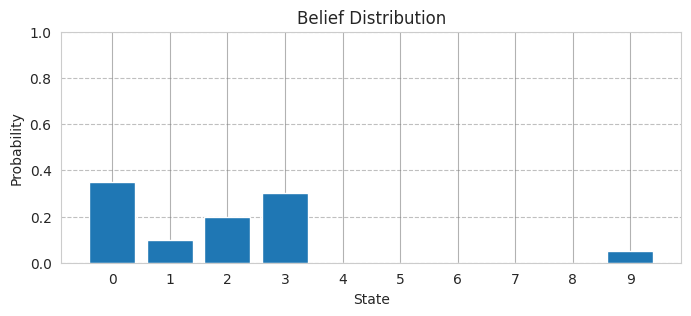

In [21]:
def perfect_predict(belief: np.ndarray, move: int) -> np.ndarray:
    """
    Move the position by `move` spaces with perfect prediction.

    Shifts the belief distribution where positive is to the right, and
    negative is to the left. Uses circular indexing for wrap-around.

    :param belief: Array representing current belief distribution
    :param move: Number of positions to move (positive=right, negative=left)
    :return: Updated belief distribution after movement
    """
    n = len(belief)
    result = np.zeros(n)
    for i in range(n):
        result[i] = belief[(i - move) % n]
    return result


belief = np.array([0.35, 0.1, 0.2, 0.3, 0, 0, 0, 0, 0, 0.05])
ut.plot_belief(belief)

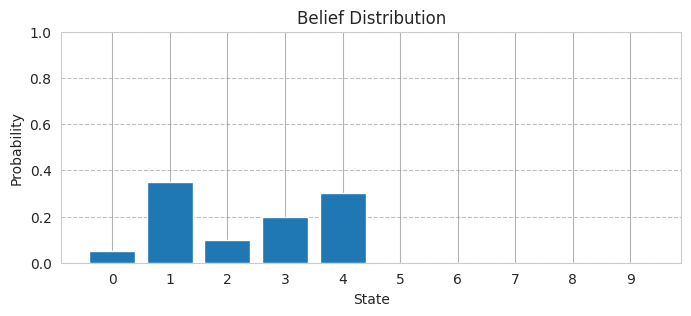

In [22]:
new_belief = perfect_predict(belief, 1)
ut.plot_belief(new_belief)

## Terminology

- system: what we are trying to model
    - E.g., the dog
- state: configuration of the system
    - E.g., the position of the dog
- The filter produces an estimated state of the system
- process model: the dog moves one or more positions at each time st4ep

## Adding Uncertainty to the Prediction

- Assume that the sensor's movement measurement $z$ is
  - 80% to be correct
  - 10% to overshoot by 1
  - 10% to undershoot by 1

- If movement measurement is 4, then the dog is:
  - 80% likely to have moved to the right
  - 10% likely to have moved 3 or 5 spaces to the right

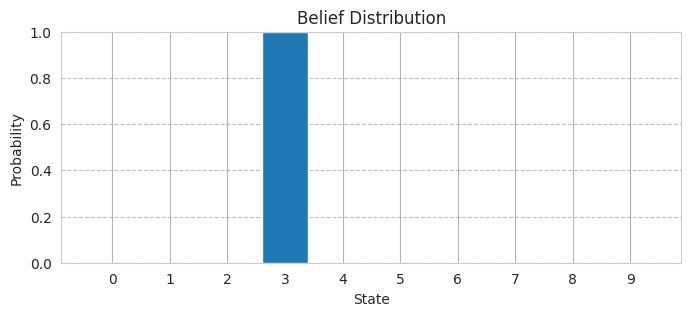

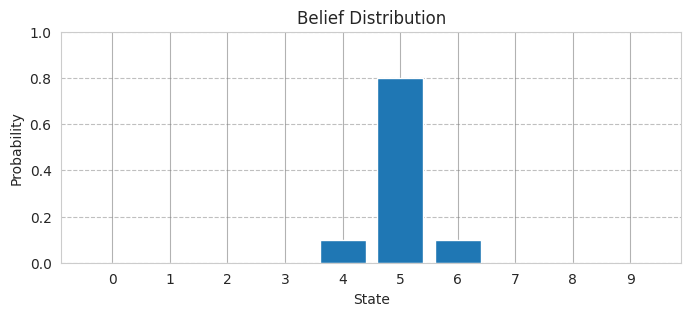

In [23]:
def predict_move(
    belief: np.ndarray,
    move: int,
    p_under: float,
    p_correct: float,
    p_over: float,
) -> np.ndarray:
    """
    Predict movement with uncertainty in the motion model.

    Models imperfect movement where the actual displacement can differ from
    the measured movement by ±1 position with specified probabilities.

    :param belief: Array representing current belief distribution
    :param move: Measured movement (number of positions)
    :param p_under: Probability of undershooting by 1 position
    :param p_correct: Probability of correct movement
    :param p_over: Probability of overshooting by 1 position
    :return: Prior belief distribution after movement prediction
    """
    n = len(belief)
    prior = np.zeros(n)
    for i in range(n):
        prior[i] = (
            belief[(i - move) % n] * p_correct
            + belief[(i - move - 1) % n] * p_over
            + belief[(i - move + 1) % n] * p_under
        )
    return prior


belief = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ut.plot_belief(belief)

move = 2
prior = predict_move(belief, move, 0.1, 0.8, 0.1)
ut.plot_belief(prior)

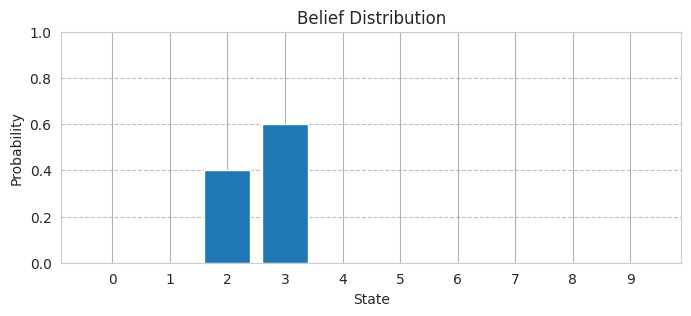

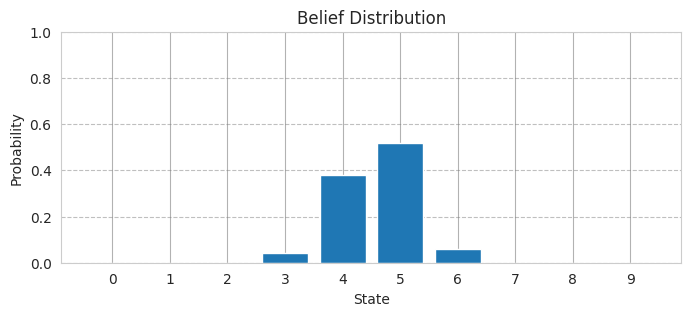

In [24]:
# Assume the belief is not correct.
belief = [0, 0, 0.4, 0.6, 0, 0, 0, 0, 0, 0]
ut.plot_belief(belief)

move = 2
prior = predict_move(belief, move, 0.1, 0.8, 0.1)
ut.plot_belief(prior)

- After the update with the noisy sensor there is always some lost information

In [25]:
from ipywidgets import interact, IntSlider

In [28]:
belief = np.array([1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
predict_beliefs = []
predict_beliefs.append(belief)
print("Initial belief:", belief)

for i in range(100):
    belief = predict_move(belief, 1, 0.1, 0.8, 0.1)
    predict_beliefs.append(belief)
print("Final Belief:", belief)


# Make an interactive plot.
def show_prior(step: int) -> None:
    """
    Display belief distribution at a specific step.

    Interactive callback function to visualize how belief evolves over time.

    :param step: Time step to display (1-indexed)
    """
    ut.plot_belief(predict_beliefs[step - 1])
    plt.title(f"Step {step}")
    plt.show()


interact(show_prior, step=IntSlider(value=1, max=len(predict_beliefs)));

Initial belief: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Final Belief: [0.10407069 0.10329322 0.10125784 0.09874205 0.09670682 0.09592945
 0.09670682 0.09874205 0.10125784 0.10329322]


interactive(children=(IntSlider(value=1, description='step', max=101), Output()), _dom_classes=('widget-intera…

In [30]:
def predict_move_convolution(pdf, offset, kernel):
    N = len(pdf)
    kN = len(kernel)
    width = int((kN - 1) / 2)

    prior = np.zeros(N)
    for i in range(N):
        for k in range (kN):
            index = (i + (width-k) - offset) % N
            prior[i] += pdf[index] * kernel[k]
    return prior

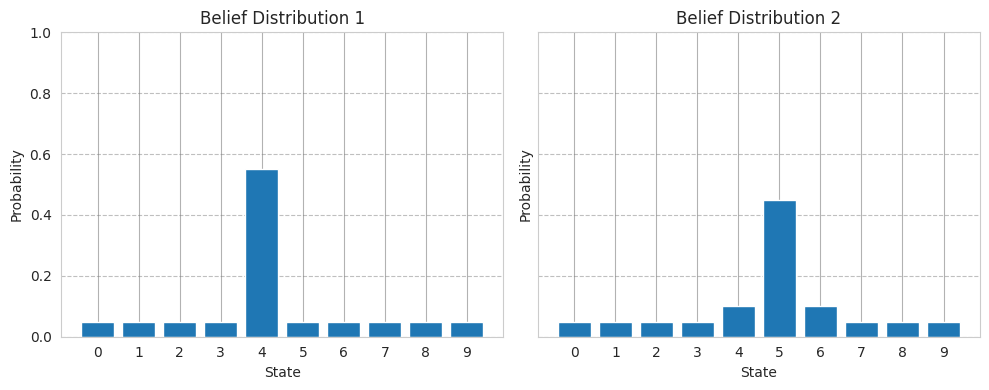

In [38]:
belief = [.05, .05, .05, .05, .55, .05, .05, .05, .05, .05]

prior = predict_move_convolution(belief, offset=1, kernel=[.1, .8, .1])

ut.plot_beliefs(belief, prior)

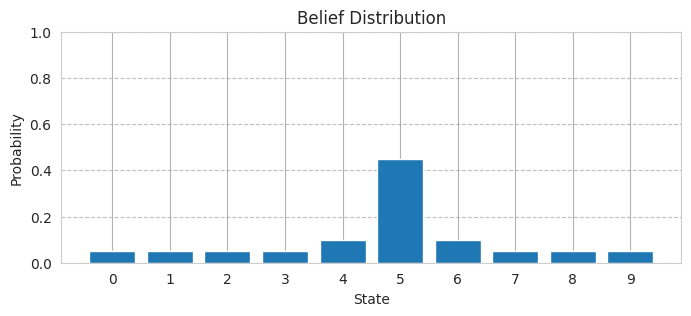

In [33]:
# Using filterpy.

from filterpy.discrete_bayes import predict

belief = [.05, .05, .05, .05, .55, .05, .05, .05, .05, .05]
prior = predict(belief, offset=1, kernel=[.1, .8, .1])
ut.plot_belief(prior)

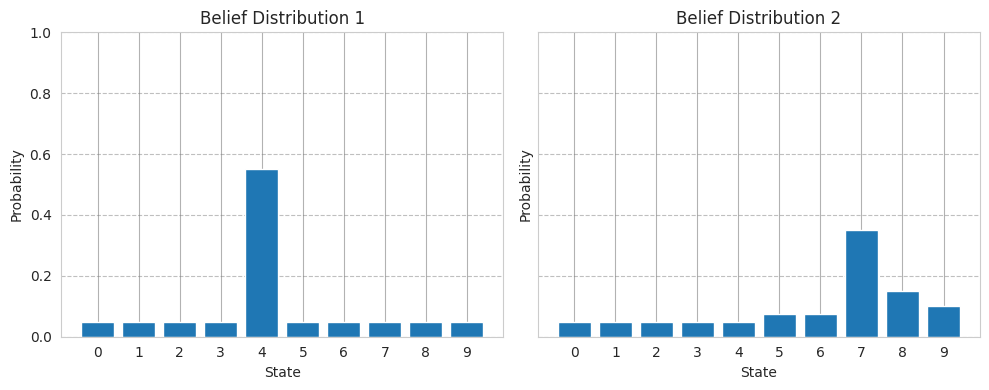

In [40]:
belief = [.05, .05, .05, .05, .55, .05, .05, .05, .05, .05]
prior = predict(belief, offset=3, kernel=[.05, .05, .6, .2, .1])

ut.plot_beliefs(belief, prior)

## Integrating Measurements and Updates

- Each prediction loses information / knowledge
- With each update we incorporate the measurement into the estimate, which improvoves knowledge
- The output of the update step is then fed into the next prediction

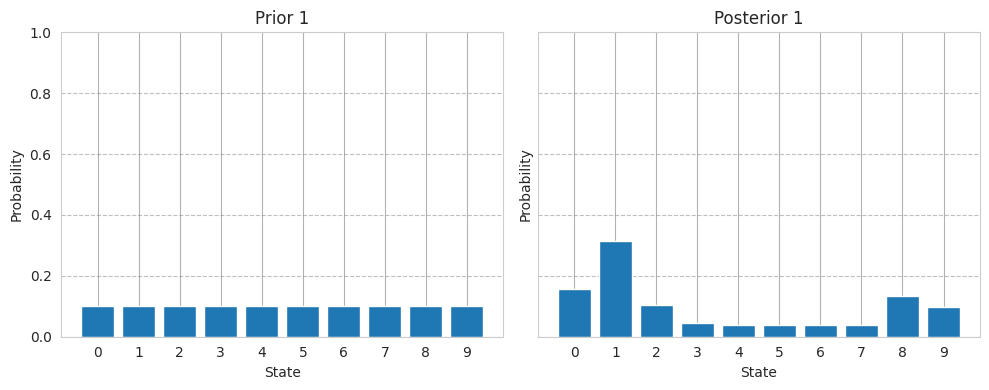

In [52]:
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])
# Sensor measurements are imperfect.
kernel = (.1, .8, .1)


# We don't have any information. The dog could be anywhere.
prior1 = np.array([.1] * 10)

# The sensor tells that the dog is in front of a door.
likelihood = lh_hallway(hallway, z=1, z_prob=.75)
posterior1 = update(likelihood, prior)

ut.plot_beliefs(prior1, posterior1, title1="Prior 1", title2="Posterior 1")

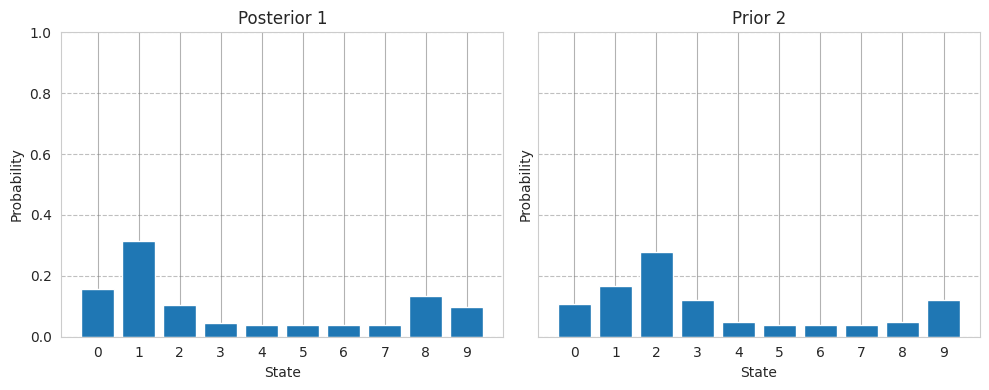

In [51]:
# The sensor says that the dog moved to the right.
move = 1
prior2 = predict(posterior1, move, kernel)
ut.plot_beliefs(posterior1, prior2, title1="Posterior1", title2="Prior2")

# The probabilities move to the right and get smeared a bit.

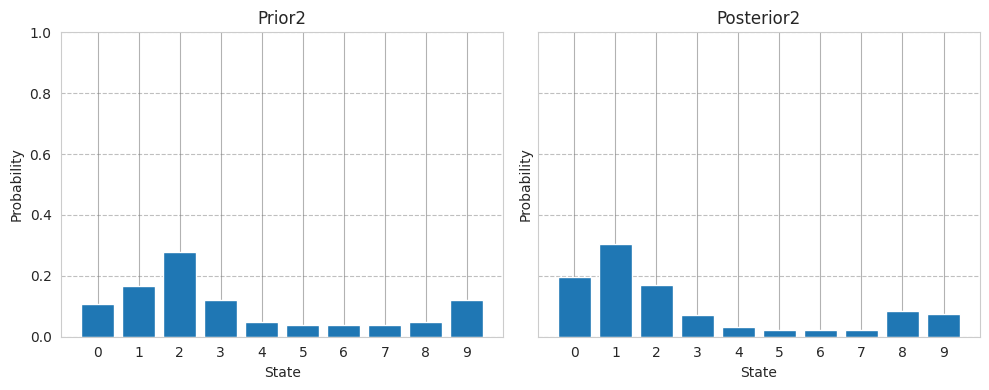

In [53]:
# The sensor senses another door.
likelihood = lh_hallway(hallway, z=1, z_prob=.75)
posterior2 = update(likelihood, prior2)

ut.plot_beliefs(prior2, posterior2, title1="Prior2", title2="Posterior2")